In [6]:
import os
from utils import get_data, clean_data, clean_weather_data, plot_by_months
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import shapiro, kstest
import numpy as np

import seaborn as sns
sns.set_style('whitegrid')
plt.style.use("fivethirtyeight")

In [7]:
elina_df = get_data(r'c:\Users\olish\Documents\ml_projects\Steps_Predictor\model\data\raw\elina_export.xml')
elina_df["user"]="elina"

oli_df = get_data(r'c:\Users\olish\Documents\ml_projects\Steps_Predictor\model\data\raw\elina_export.xml')
oli_df["user"] = "oli"

dfs_to_concat = [elina_df, oli_df]
df = pd.concat(dfs_to_concat)

oli = df[df['user']=='oli']
elina = df[df['user']=='elina']

In [8]:
df.tail()

,type,source_name,source_version,device,unit,creation_date,start_date,end_date,value,user
232553,HKQuantityTypeIdentifierAppleWalkingSteadiness,Elina’s iPhone,2780.0.31,Elina’s iPhone,%,2024-08-26 06:58:29 +0200,2024-08-19 02:00:00 +0200,2024-08-26 02:00:00 +0200,1,oli
232554,HKQuantityTypeIdentifierAppleWalkingSteadiness,Elina’s iPhone,2780.0.31,Elina’s iPhone,%,2024-09-02 06:42:12 +0200,2024-08-26 02:00:00 +0200,2024-09-02 02:00:00 +0200,0.986955,oli
232555,HKQuantityTypeIdentifierAppleWalkingSteadiness,Elina’s iPhone,2780.0.31,Elina’s iPhone,%,2024-09-09 07:33:18 +0200,2024-09-02 02:00:00 +0200,2024-09-09 02:00:00 +0200,1,oli
232556,HKQuantityTypeIdentifierAppleWalkingSteadiness,Elina’s iPhone,2780.0.31,Elina’s iPhone,%,2024-09-16 08:41:21 +0200,2024-09-09 02:00:00 +0200,2024-09-16 02:00:00 +0200,1,oli
232557,HKQuantityTypeIdentifierAppleWalkingSteadiness,Elina’s iPhone,2780.0.31,Elina’s iPhone,%,2024-09-23 07:06:30 +0200,2024-09-16 02:00:00 +0200,2024-09-23 02:00:00 +0200,0.996475,oli


# Inspection

In [9]:
df.shape

(465116, 10)

# Cleaning
Output: a dataframe that contains a daily date column and its corresponding values.  

In [10]:
clean_df = clean_data(df)
oli = clean_data(oli)
elina = clean_data(elina)

In [11]:
print(clean_df.head())
print(oli.head())
print(elina.head())

        date   user  value
0 2020-01-04  elina    184
1 2020-01-04    oli    184
2 2020-03-29  elina    185
3 2020-03-29    oli    185
4 2020-03-30  elina   5432
        date user  value
0 2020-01-04  oli    184
1 2020-03-29  oli    185
2 2020-03-30  oli   5432
3 2020-03-31  oli   2189
4 2020-04-01  oli   2933
        date   user  value
0 2020-01-04  elina    184
1 2020-03-29  elina    185
2 2020-03-30  elina   5432
3 2020-03-31  elina   2189
4 2020-04-01  elina   2933


In [12]:
type(df['value'].iloc[0])

str

In [13]:
user_list = [oli, elina] 
for user in user_list:
    user.drop(columns='user', errors='ignore', inplace=True)

In [14]:
print(clean_df.head())
print(f"oli's df: \n{oli.head()}")
print(f"elina's df: \n{elina.head()}")

        date   user  value
0 2020-01-04  elina    184
1 2020-01-04    oli    184
2 2020-03-29  elina    185
3 2020-03-29    oli    185
4 2020-03-30  elina   5432
oli's df: 
        date  value
0 2020-01-04    184
1 2020-03-29    185
2 2020-03-30   5432
3 2020-03-31   2189
4 2020-04-01   2933
elina's df: 
        date  value
0 2020-01-04    184
1 2020-03-29    185
2 2020-03-30   5432
3 2020-03-31   2189
4 2020-04-01   2933


In [15]:
print(f"oli's shape: \n{oli.shape[0]}")
print(f"elina's shape: \n{elina.shape[0]}")
print(f"oli and elina's combined shape: \n{oli.shape[0] + elina.shape[0]}")

oli's shape: 
1645
elina's shape: 
1645
oli and elina's combined shape: 
3290


In [16]:
1645/365

4.506849315068493

### Conclusions:
- The cummulated count for each day does not match the count shown on the app interface
- Data types: datetime and int
- value is continuous data
- date is ordinal
- There is four and a half years worth of data



# Quality

In [17]:
date_duplicates = clean_df.drop(labels=('date'), axis=1).duplicated().sum()
print(f'there are {date_duplicates} duplicates in the date col.')

there are 314 duplicates in the date col.


Text(0, 0.5, 'num of samples')

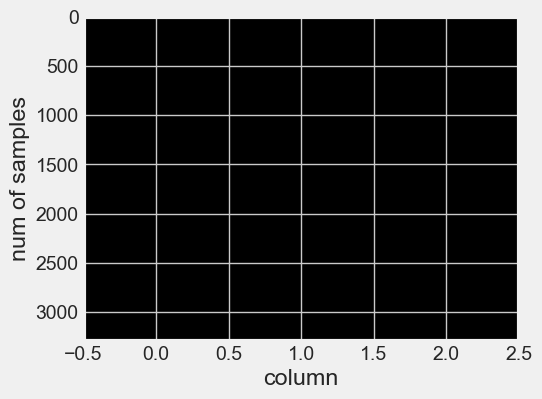

In [18]:
plt.figure(figsize=(5,4))
plt.imshow(clean_df.isna(), aspect='auto', interpolation='nearest', cmap='gray')
plt.xlabel("column")
plt.ylabel("num of samples")

In [19]:
elina_description = elina['value'].describe()
oli_description = oli['value'].describe()

elina_desc = pd.DataFrame(elina_description).rename(columns={'value': "elina"})
oli_desc = pd.DataFrame(oli_description).rename(columns={'value': "oli"})

combined_description = pd.concat([elina_desc, oli_desc], axis=1)
print(combined_description)

              elina           oli
count   1645.000000   1645.000000
mean    4520.144681   4520.144681
std     3050.355697   3050.355697
min        6.000000      6.000000
25%     2298.000000   2298.000000
50%     4049.000000   4049.000000
75%     6319.000000   6319.000000
max    22171.000000  22171.000000


In [20]:
elina.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1645 entries, 0 to 1644
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    1645 non-null   datetime64[ns]
 1   value   1645 non-null   int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 25.8 KB


In [21]:
oli.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1645 entries, 0 to 1644
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    1645 non-null   datetime64[ns]
 1   value   1645 non-null   int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 25.8 KB


# EDA

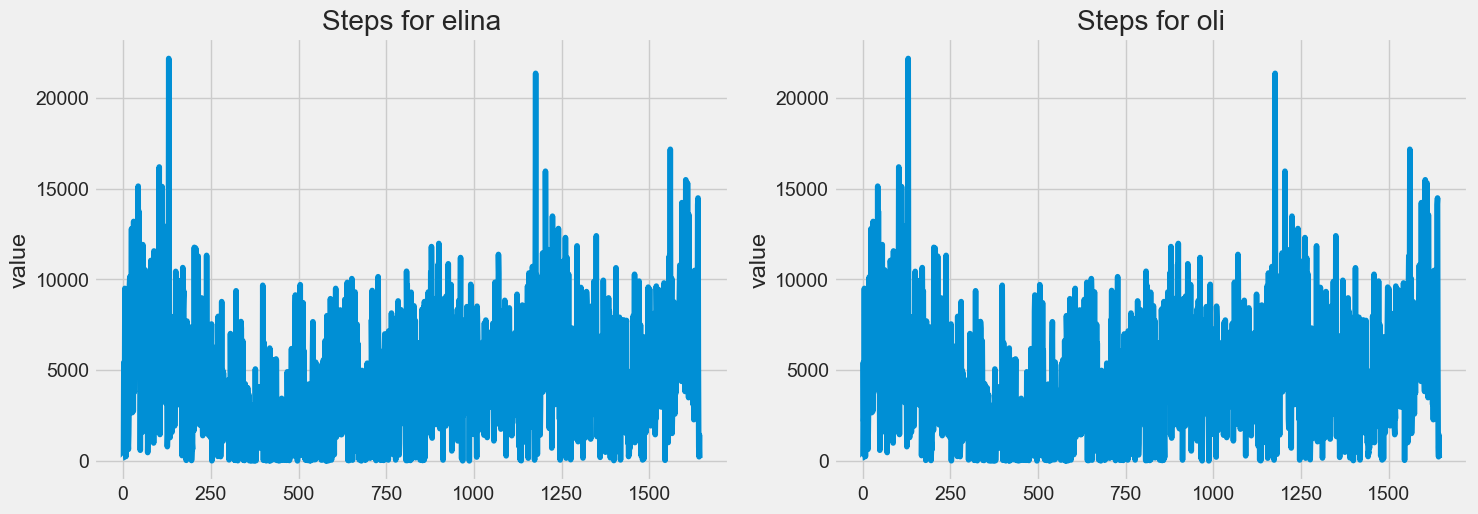

In [22]:
user_list = [elina, oli]
user_names = ["elina", "oli"]

plt.figure(figsize=(15, 10))
plt.subplots_adjust(top=1.25, bottom=1.2)

for i, user in enumerate(user_list, 1):
    plt.subplot(2, 2, i)
    user['value'].plot()
    plt.ylabel('value')
    plt.xlabel(None)
    plt.title(f"Steps for {user_names[i-1]}")
    
plt.tight_layout()

array([[<Axes: >, <Axes: >, <Axes: >, <Axes: >]], dtype=object)

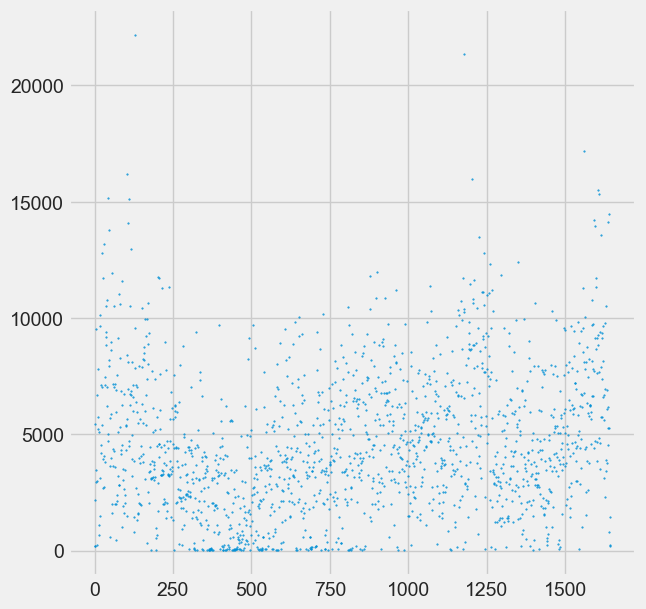

In [23]:
oli["value"].plot(lw=0, marker='.', subplots=True, layout=(-1,4), figsize=(30,7), markersize=1)

In [24]:
def freedman_diaconis(value):
    q1 = np.percentile(value, 25)
    q3 = np.percentile(value, 75)
    iqr = q3-q1
    n = len(value)
    bin_width = 2 * iqr * n **(-1/3)

    return int((np.max(value) - np.min(value)) / bin_width)

In [25]:
value = oli['value']

num_bins = freedman_diaconis(value)
num_bins

32

In [26]:
oli.head()

,date,value
0,2020-01-04,184
1,2020-03-29,185
2,2020-03-30,5432
3,2020-03-31,2189
4,2020-04-01,2933


<Axes: >

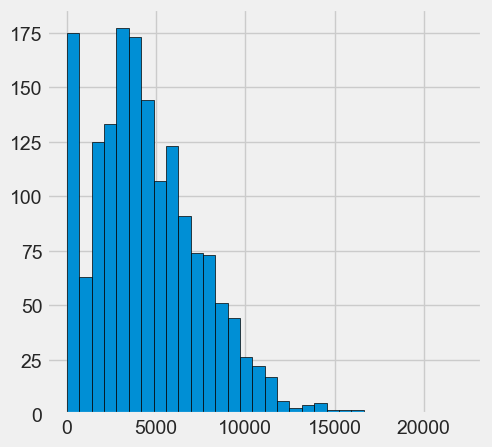

In [27]:
oli["value"].hist( bins=32, figsize=(5,5), edgecolor='black')

In [28]:
value.mode()

0    13
1    42
2    44
3    83
Name: value, dtype: int64

In [30]:
oli.head(1)

,date,value
0,2020-01-04,184


In [33]:
type(oli["value"][0])

numpy.int64

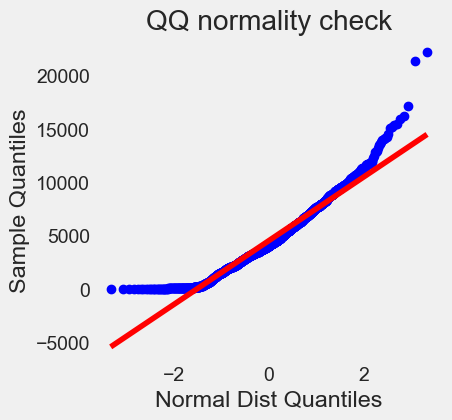

In [29]:
plt.figure(figsize=(4,4))
stats.probplot(oli["value"], dist='norm', plot=plt)
plt.title('QQ normality check')
plt.xlabel('Normal Dist Quantiles')
plt.ylabel('Sample Quantiles')
plt.grid()
plt.show()

In [29]:
stat, p_val = shapiro(oli["value"])

print('Shapiro-Wilk Test Statistie: ', stat)
print('Shapiro-Wilk p-value: ', p_val)

if p_val > 0.05:
    print('Sample appears to be normally distributed.  Fail to reject H0')
else:
    print('sample does not appear to be normally distributed. Reject H0')


Shapiro-Wilk Test Statistie:  0.972831515768469
Shapiro-Wilk p-value:  2.1903782993629407e-19
sample does not appear to be normally distributed. Reject H0


In [30]:

stat, p_val = kstest(oli["value"], 'norm', args=(np.mean(value), np.std(value)))

print('K-S Test Statistic: ', stat)
print('K-S p-value: ', p_val)

if p_val>0.05:
    print('Sample appears to be normally distributed. Fail to reject H0')
else:
    print('Sample does not appear to be normally distributed. reject H0')

K-S Test Statistic:  0.060018513446292054
K-S p-value:  6.253933771305544e-07
Sample does not appear to be normally distributed. reject H0


# Comparing Datasets

In [271]:
import sys
import os
sys.path.append(r'C:\Users\olish\Documents\ml_projects\Steps_Predictor\model')
from src.components.data_ingestion import DataIngestion, DataIngestionConfig
from src.components.data_cleaning import DataCleaning

In [272]:
from dotenv import load_dotenv

load_dotenv()


True

(Env Variable Code)

from src.components.data_ingestion import DataIngestion
from src.components.data_cleaning import DataCleaning 

ingestion_obj = DataIngestion()
train, test = ingestion_obj.initiate_data_ingestion()

cleaning_obj = DataCleaning()
cleaned_train_data, cleaned_test_data = cleaning_obj.initiate_data_cleaning(train, test)

In [31]:
print(f"oli shape: {oli.shape}")

oli shape: (2072, 2)


In [32]:
print(f"elina_shape: {elina.shape}")

elina_shape: (1645, 2)


In [3]:
user_list = [elina, oli]
user_names = ["elina", "oli"]

plt.figure(figsize=(15, 10))
plt.subplots_adjust(top=1.25, bottom=1.2)

for i, user in enumerate(user_list, 1):
    plt.subplot(2, 2, i)
    stats.probplot(user["value"], dist="norm", plot=plt)
    plt.ylabel('value')
    plt.xlabel(None)
    plt.title(f"qq plot for {user_names[i-1]}")
    
plt.tight_layout()

NameError: name 'elina' is not defined

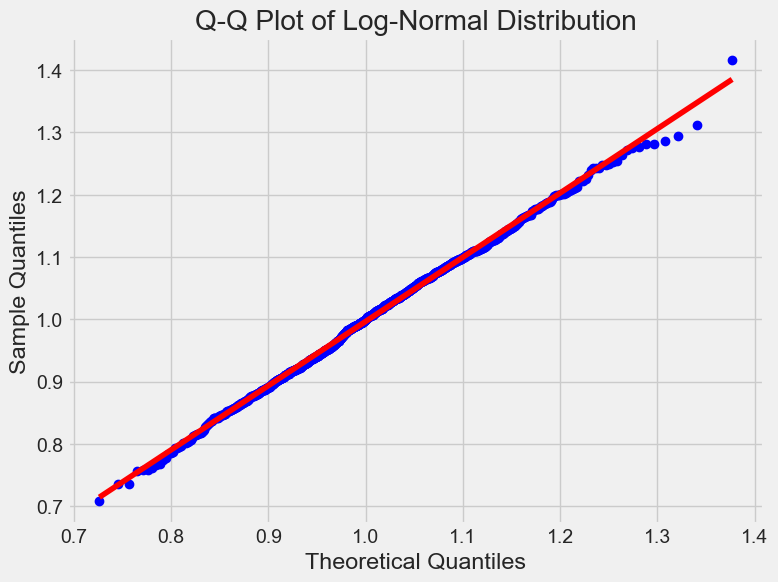

In [52]:
mu = 0  # Mean of the underlying normal distribution
sigma = 0.1  # Standard deviation of the underlying normal distribution
size = 1000  # Number of samples

# Generate log-normal distributed data
data = np.random.lognormal(mean=mu, sigma=sigma, size=size)

# Step 2: Create the Q-Q plot
plt.figure(figsize=(8, 6))
stats.probplot(data, dist="lognorm", sparams=(sigma,), plot=plt)
plt.title('Q-Q Plot of Log-Normal Distribution')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.grid(True)

# Show the plot
plt.show()

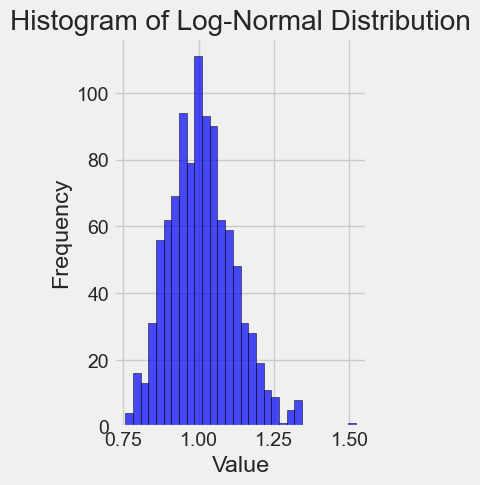

In [284]:
plt.subplot(1, 2, 1)  # 1 row, 2 columns, 1st subplot
plt.hist(data, bins=30, color='blue', alpha=0.7, edgecolor='black')
plt.title('Histogram of Log-Normal Distribution')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True)

array([[<Axes: title={'center': 'value'}>]], dtype=object)

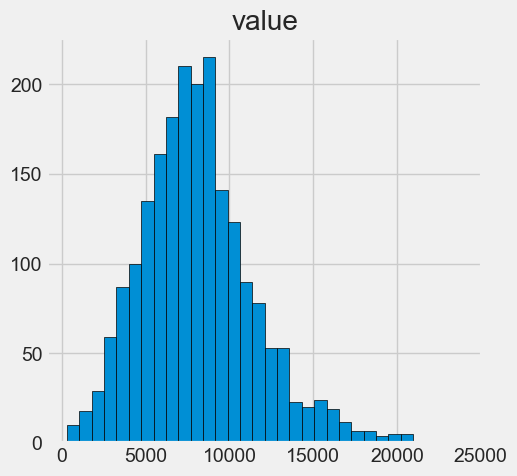

In [285]:
clean_df.hist( bins=32, figsize=(5,5), edgecolor='black')

# Potential distributions

right skewed histograms:
-log-normal: high frequency in low values, low frequency in high values
-exponential
-gamma
-weibull
-chi square

bimodal dist - significan variance from weekends to week days

# Feature Engineering

-is there any value in examining the daily chang in step data?

In [39]:
clean_df.head()

,date,user,value
0,2018-11-18,oli,4390
1,2018-11-19,oli,8335
2,2018-11-20,oli,6946
3,2018-11-21,oli,8350
4,2018-11-22,oli,11054


In [40]:
specific_value = clean_df.loc[0, 'date']  # Accessing the first value in the 'date' column
value_type = type(specific_value)
value_type

pandas._libs.tslibs.timestamps.Timestamp

In [41]:
clean_df['day'] = clean_df['date'].dt.day_name() 

daily_df = clean_df.drop(columns="date")
daily_df.head()

,user,value,day
0,oli,4390,Sunday
1,oli,8335,Monday
2,oli,6946,Tuesday
3,oli,8350,Wednesday
4,oli,11054,Thursday


In [42]:
daily_df.shape

(3717, 3)

In [46]:
oli_daily_df = daily_df[daily_df['user']=='oli']
elina_daily_df = daily_df[daily_df['user']=='elina']



In [290]:
summed_df = daily_df.groupby('day')['value'].sum().reset_index()
summed_df['value'] = summed_df['value'] / 10000

summed_df.head()

,day,value
0,Friday,268.2326
1,Monday,236.1664
2,Saturday,232.6376
3,Sunday,213.8651
4,Thursday,246.1699


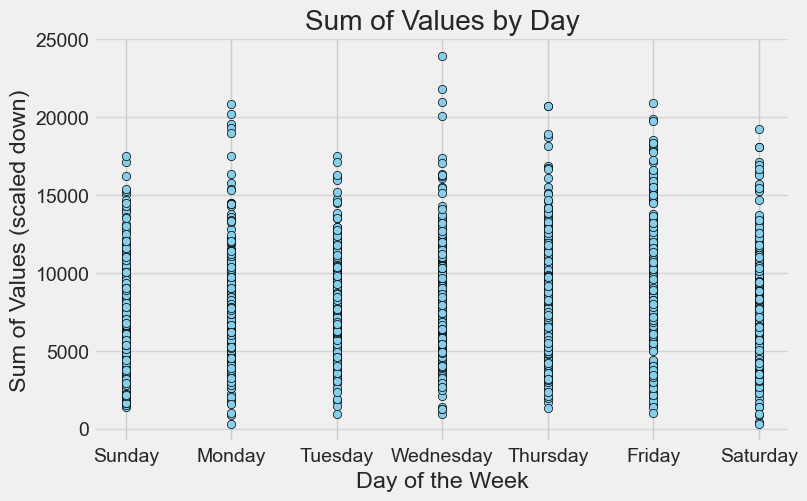

In [48]:
plt.figure(figsize=(8, 5))
plt.scatter(oli_daily_df['day'], oli_daily_df['value'], color='skyblue', edgecolor='black')

plt.title('Sum of Values by Day')
plt.xlabel('Day of the Week')
plt.ylabel('Sum of Values (scaled down)')

plt.grid(axis='y', alpha=0.75)

plt.show()

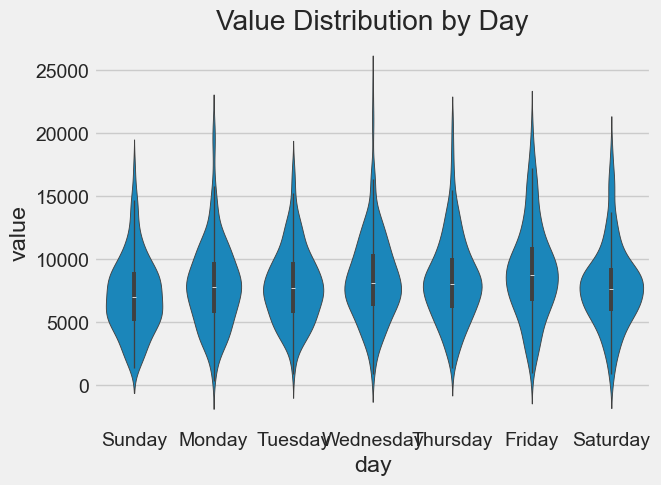

In [49]:
sns.violinplot(data=oli_daily_df, x='day', y='value')
plt.title("Value Distribution by Day")
plt.show()

# Data Engineering

In [54]:
csv_dir = r"C:\Users\olish\Documents\ml_projects\Steps_Predictor\model\data\weather_exports"

csv_files = [f for f in os.listdir(csv_dir) if f.endswith('.csv')]

dfs = []

for file in csv_files:
    file_path = os.path.join(csv_dir, file)
    df = pd.read_csv(file_path)  
    dfs.append(df)  

weather_df = pd.concat(dfs, ignore_index=True)

In [55]:
weather_df.head()

,name,datetime,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,...,solarenergy,uvindex,severerisk,sunrise,sunset,moonphase,conditions,description,icon,stations
0,malmo,2020-01-01,42.1,35.8,39.5,35.7,31.7,33.8,35.0,84.0,...,1.4,1,NaN,2020-01-01T08:36:46,2020-01-01T15:46:04,0.20,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,"06180099999,02615099999,E5732,02611099999,0617..."
1,malmo,2020-01-02,36.7,34.8,35.6,30.8,27.4,29.4,33.2,91.1,...,0.9,1,NaN,2020-01-02T08:36:32,2020-01-02T15:47:15,0.23,Overcast,Cloudy skies throughout the day.,cloudy,"06180099999,02615099999,E5732,02611099999,0617..."
2,malmo,2020-01-03,43.9,36.0,40.8,39.2,27.5,34.9,38.2,90.6,...,0.5,0,NaN,2020-01-03T08:36:14,2020-01-03T15:48:30,0.25,"Rain, Partially cloudy",Partly cloudy throughout the day with rain in ...,rain,"06180099999,02615099999,E5732,02611099999,0617..."
3,malmo,2020-01-04,42.1,36.3,40.0,34.4,28.4,32.6,32.7,75.9,...,1.7,1,NaN,2020-01-04T08:35:52,2020-01-04T15:49:48,0.30,"Rain, Partially cloudy",Partly cloudy throughout the day with a chance...,rain,"06180099999,02615099999,E5732,02611099999,0617..."
4,malmo,2020-01-05,41.3,32.0,37.5,37.5,27.2,33.1,33.6,86.4,...,1.2,1,NaN,2020-01-05T08:35:26,2020-01-05T15:51:10,0.33,"Rain, Partially cloudy",Partly cloudy throughout the day with rain.,rain,"06180099999,02615099999,E5732,02611099999,0617..."


In [56]:
weather_df['datetime'] = pd.to_datetime(weather_df['datetime'])
weather_df = weather_df.reset_index(drop=True)

df_shape = weather_df.shape[0]
name_unique = weather_df['name'].unique()
duplicate_dates = weather_df['datetime'].duplicated().sum()
cols_list = weather_df.columns
severe_nan_count = weather_df['severerisk'].isna().sum()
conditions_unique = weather_df['conditions'].unique()
description_unique = weather_df['description'].unique()
icons_unique = weather_df['icon'].unique()

print(f"Shape of DF: {df_shape}")

print(f"List of Columns: + {cols_list}")

print(f"Number of Duplicated Dates: {duplicate_dates}")
print(f"Nan Count of severrisk Column: {severe_nan_count}")

print(f"name column unique values: {name_unique}")
print(f"condition Column unique values: {conditions_unique}")
print(f"description Column unique values: {description_unique}")
print(f"icon Column unique values: {icons_unique}")

Shape of DF: 1461
List of Columns: + Index(['name', 'datetime', 'tempmax', 'tempmin', 'temp', 'feelslikemax',
       'feelslikemin', 'feelslike', 'dew', 'humidity', 'precip', 'precipprob',
       'precipcover', 'preciptype', 'snow', 'snowdepth', 'windgust',
       'windspeed', 'winddir', 'sealevelpressure', 'cloudcover', 'visibility',
       'solarradiation', 'solarenergy', 'uvindex', 'severerisk', 'sunrise',
       'sunset', 'moonphase', 'conditions', 'description', 'icon', 'stations'],
      dtype='object')
Number of Duplicated Dates: 0
Nan Count of severrisk Column: 740
name column unique values: ['malmo']
condition Column unique values: ['Partially cloudy' 'Overcast' 'Rain, Partially cloudy' 'Rain, Overcast'
 'Clear' 'Snow, Rain, Overcast' 'Snow, Rain, Partially cloudy' 'Rain'
 'Snow, Partially cloudy' 'Snow, Overcast' 'Snow' 'Snow, Rain']
description Column unique values: ['Partly cloudy throughout the day.' 'Cloudy skies throughout the day.'
 'Partly cloudy throughout the day wit

In [57]:
unique_count = weather_df["description"].nunique()
print(f"Number of Unique Descriptions: {unique_count}")

Number of Unique Descriptions: 64


In [58]:
nans = weather_df.isna().sum()
nans

name                  0
datetime              0
tempmax               0
tempmin               0
temp                  0
feelslikemax          0
feelslikemin          0
feelslike             0
dew                   0
humidity              0
precip                0
precipprob            0
precipcover           0
preciptype          552
snow                  0
snowdepth             0
windgust              0
windspeed             0
winddir               0
sealevelpressure      0
cloudcover            0
visibility            0
solarradiation        0
solarenergy           0
uvindex               0
severerisk          740
sunrise               0
sunset                0
moonphase             0
conditions            0
description           0
icon                  0
stations              0
dtype: int64

In [59]:
weather_df["severerisk"].unique()

array([nan, 10.])

In [60]:
weather_df["preciptype"].unique()

array([nan, 'rain', 'rain,snow', 'snow'], dtype=object)

In [ ]:
clean_weather_df = clean_weather_data(weather_df)

In [62]:
pd.set_option('display.max_columns', None)
clean_weather_df.head()

,date,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,precip,precipprob,precipcover,preciptype,snow,snowdepth,windgust,windspeed,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,severerisk,sunrise,sunset,moonphase,conditions,description,icon
0,2020-01-01,5.6,2.1,4.2,2.1,-0.2,1.0,35.0,84.0,0.000,0,0.00,none,0.0,0.0,26.8,12.4,1028.4,71.9,11.5,15.8,1.4,1,0.0,08:36:46,15:46:04,0.20,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day
1,2020-01-02,2.6,1.6,2.0,-0.7,-2.6,-1.4,33.2,91.1,0.000,0,0.00,none,0.0,0.0,26.4,10.0,1021.6,96.3,4.0,10.6,0.9,1,0.0,08:36:32,15:47:15,0.23,Overcast,Cloudy skies throughout the day.,cloudy
2,2020-01-03,6.6,2.2,4.9,4.0,-2.5,1.6,38.2,90.6,0.010,100,20.83,rain,0.0,0.0,26.3,13.4,1010.4,88.0,6.3,4.1,0.5,0,0.0,08:36:14,15:48:30,0.25,"Rain, Partially cloudy",Partly cloudy throughout the day with rain in ...,rain
3,2020-01-04,5.6,2.4,4.4,1.3,-2.0,0.3,32.7,75.9,0.418,100,33.33,rain,0.0,0.0,35.6,18.1,1013.1,40.2,13.7,19.2,1.7,1,0.0,08:35:52,15:49:48,0.30,"Rain, Partially cloudy",Partly cloudy throughout the day with a chance...,rain
4,2020-01-05,5.2,0.0,3.1,3.1,-2.7,0.6,33.6,86.4,0.023,100,16.67,rain,0.0,0.0,28.4,10.6,1027.7,55.0,11.1,16.9,1.2,1,0.0,08:35:26,15:51:10,0.33,"Rain, Partially cloudy",Partly cloudy throughout the day with rain.,rain


In [65]:
clean_weather_df = clean_weather_df.rename(columns={'datetime': 'date'})
merged_weather_df = pd.merge(clean_df, clean_weather_df, on='date', how='inner')
merged_weather_df.tail()

,date,user,value,day,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,precip,precipprob,precipcover,preciptype,snow,snowdepth,windgust,windspeed,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,severerisk,sunrise,sunset,moonphase,conditions,description,icon
2827,2023-12-29,oli,3989,Friday,8.1,6.1,7.1,3.9,1.8,2.9,40.2,83.9,0.100,100,54.17,rain,0.0,0.0,38.4,25.3,996.3,84.5,13.8,11.5,1.0,1,10.0,08:37:06,15:42:53,0.58,"Rain, Partially cloudy",Partly cloudy throughout the day with a chance...,rain
2828,2023-12-30,elina,6479,Saturday,6.0,4.0,5.1,2.5,0.4,1.4,37.3,85.9,0.216,100,25.00,rain,0.0,0.0,19.5,13.4,1003.4,76.2,18.9,26.3,2.3,2,10.0,08:37:04,15:43:54,0.61,"Rain, Partially cloudy",Partly cloudy throughout the day with rain cle...,rain
2829,2023-12-30,oli,15699,Saturday,6.0,4.0,5.1,2.5,0.4,1.4,37.3,85.9,0.216,100,25.00,rain,0.0,0.0,19.5,13.4,1003.4,76.2,18.9,26.3,2.3,2,10.0,08:37:04,15:43:54,0.61,"Rain, Partially cloudy",Partly cloudy throughout the day with rain cle...,rain
2830,2023-12-31,elina,3741,Sunday,5.4,2.3,4.7,1.8,-0.4,0.6,38.9,94.1,0.217,100,37.50,rain,0.0,0.0,33.7,22.6,1005.9,88.1,9.3,6.1,0.5,1,10.0,08:36:58,15:44:58,0.64,"Rain, Partially cloudy",Partly cloudy throughout the day with rain.,rain
2831,2023-12-31,oli,10032,Sunday,5.4,2.3,4.7,1.8,-0.4,0.6,38.9,94.1,0.217,100,37.50,rain,0.0,0.0,33.7,22.6,1005.9,88.1,9.3,6.1,0.5,1,10.0,08:36:58,15:44:58,0.64,"Rain, Partially cloudy",Partly cloudy throughout the day with rain.,rain


# Weather EDA

In [68]:
oli_weather = merged_weather_df[merged_weather_df['user']=='oli'] 
elina_weather = merged_weather_df[merged_weather_df['user']=='elina'] 




In [70]:
merged_weather_df["conditions"].unique()

array(['Partially cloudy', 'Overcast', 'Rain, Partially cloudy',
       'Rain, Overcast', 'Clear', 'Snow, Rain, Overcast',
       'Snow, Rain, Partially cloudy', 'Rain', 'Snow, Partially cloudy',
       'Snow, Overcast', 'Snow', 'Snow, Rain'], dtype=object)

<BarContainer object of 1459 artists>

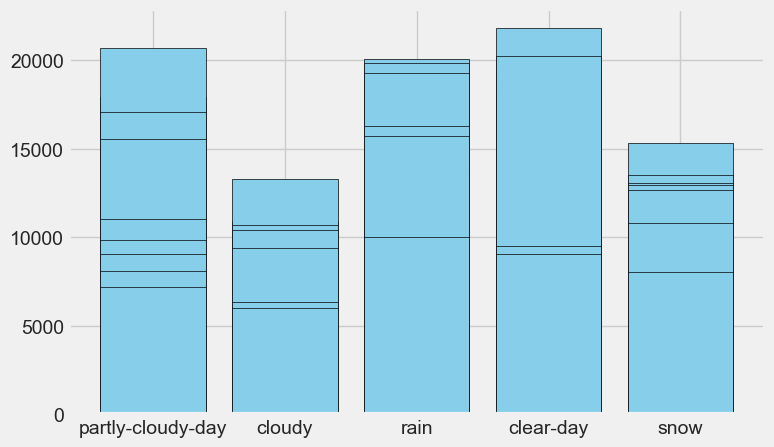

In [303]:
plt.figure(figsize=(8, 5))
plt.bar(merged_df['icon'], merged_df['value'], color='skyblue', edgecolor='black')

<BarContainer object of 1459 artists>

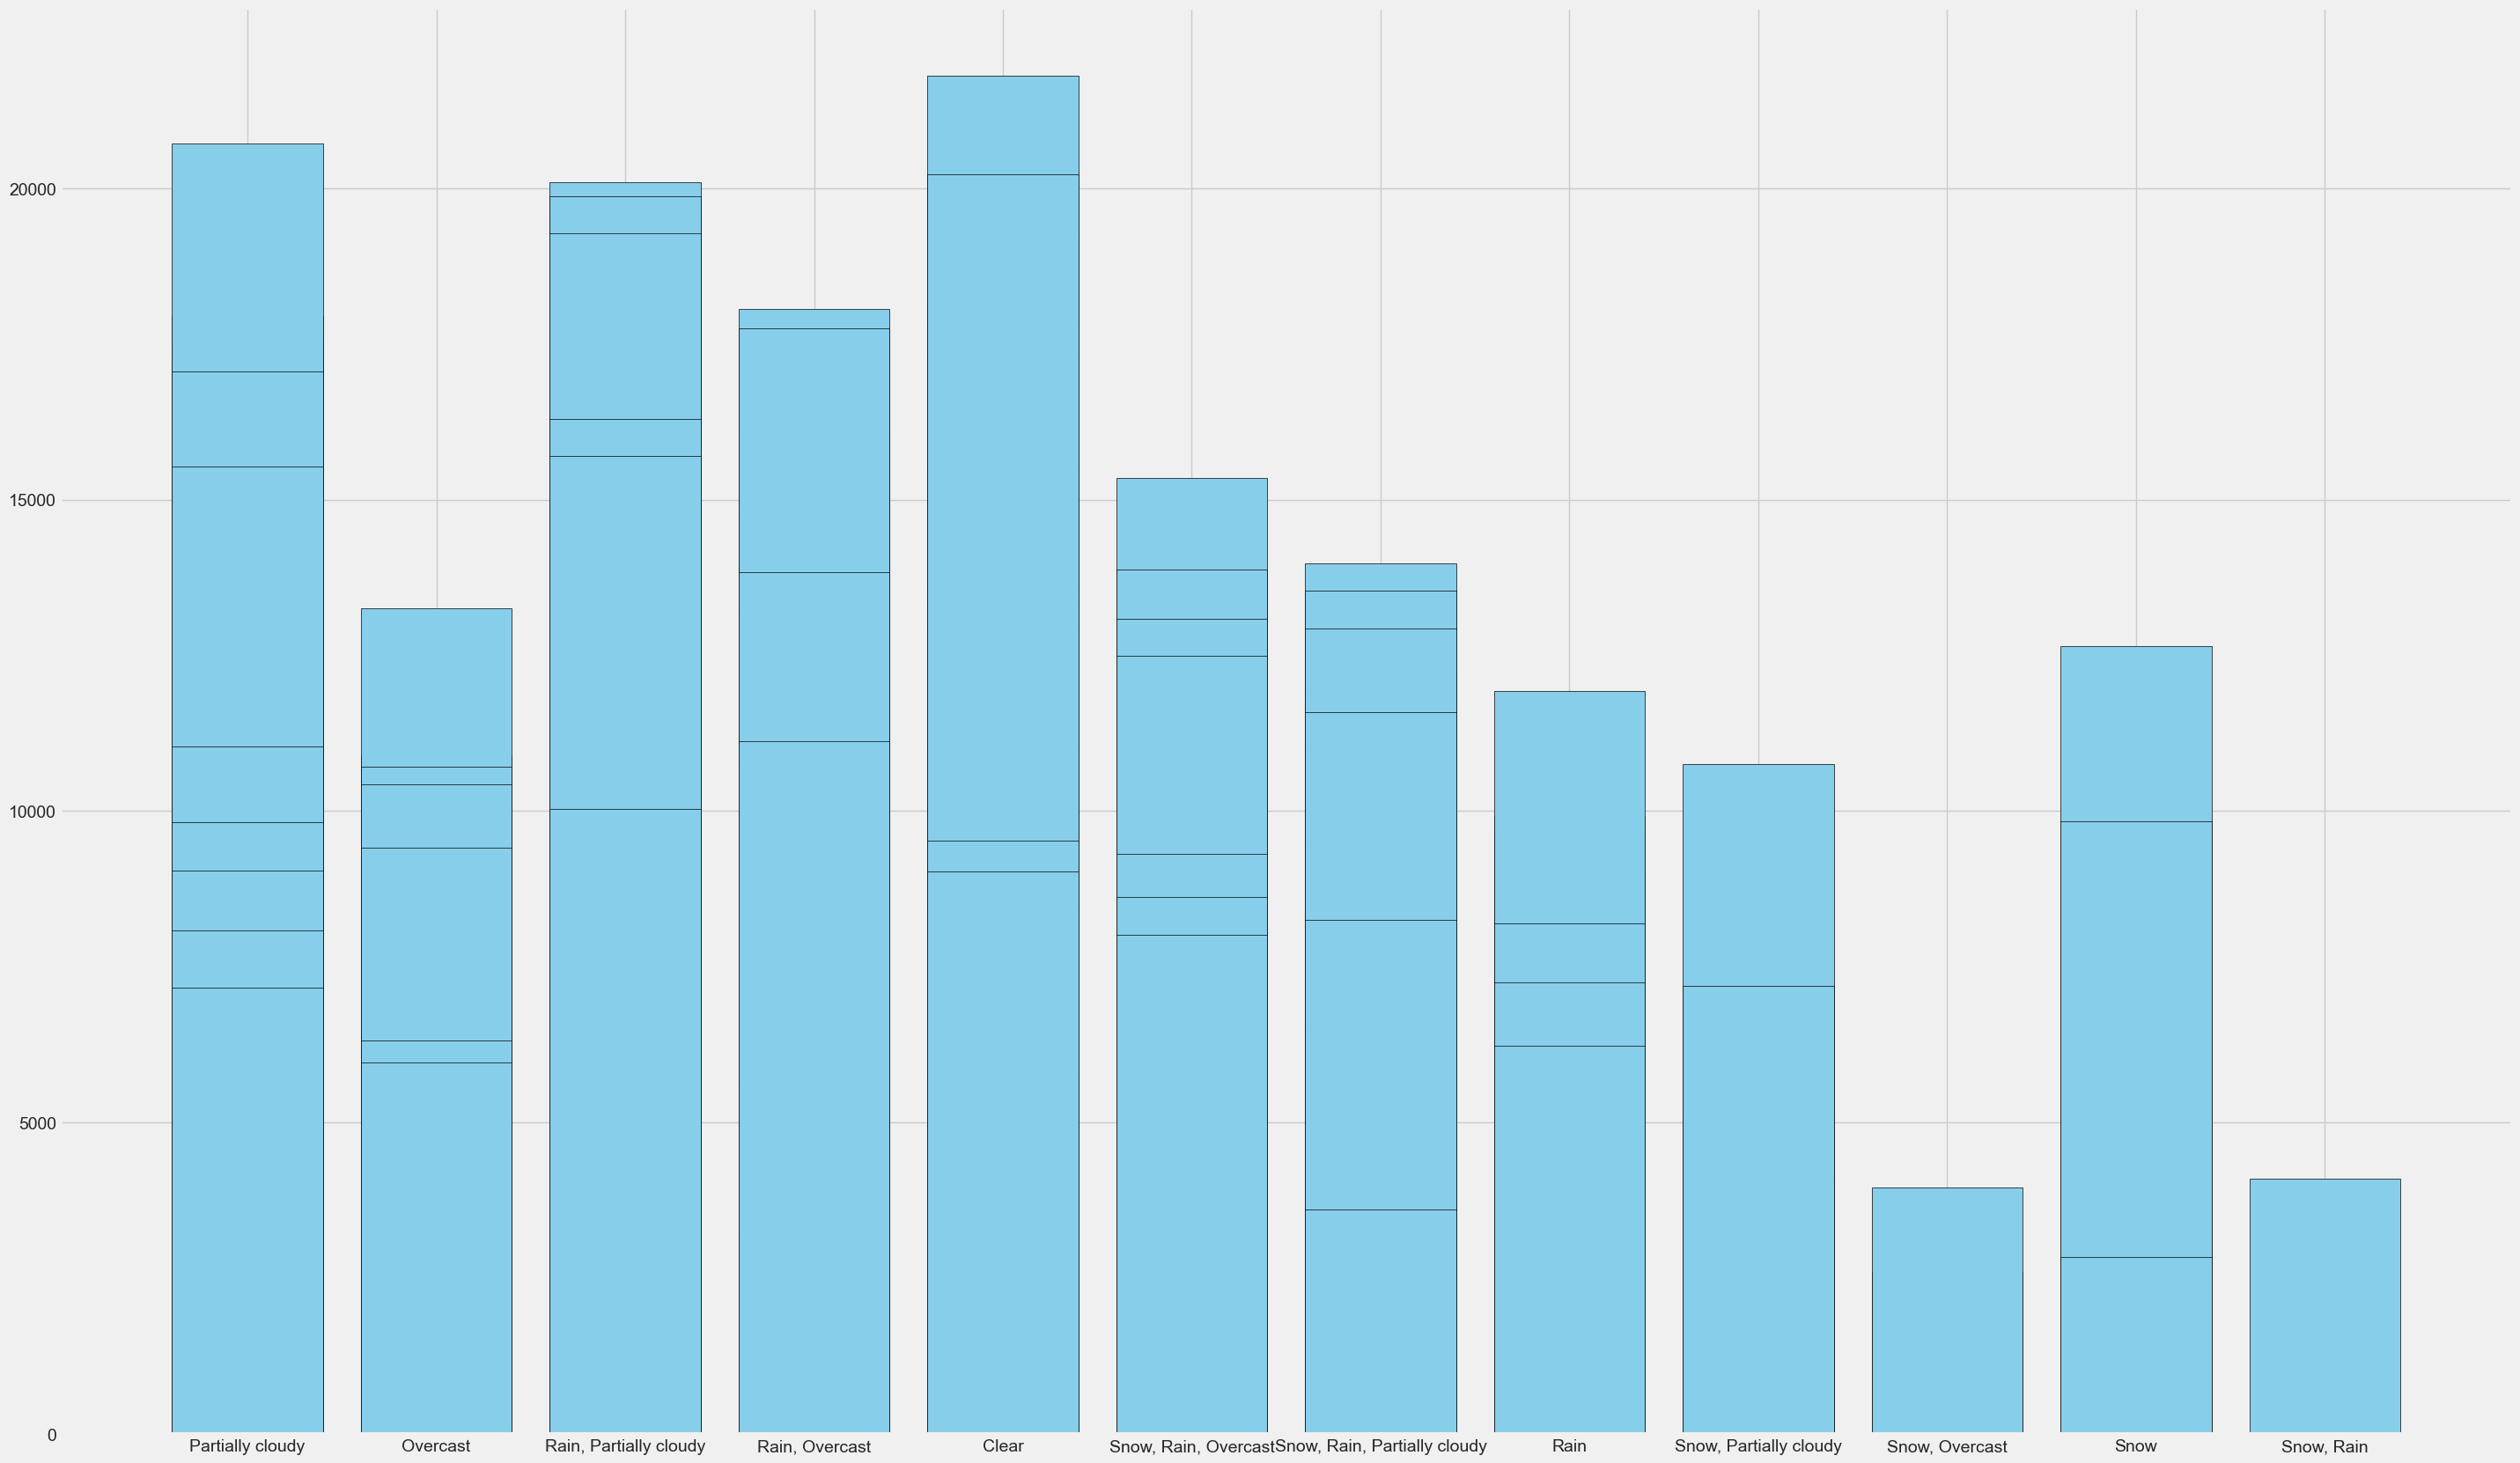

In [304]:
cols_to_keep = ['value', 'conditions']
    
conditions_df = merged_df[cols_to_keep]
plt.figure(figsize=(32, 20))
plt.bar(conditions_df['conditions'], merged_df['value'], color='skyblue', edgecolor='black')

<BarContainer object of 366 artists>

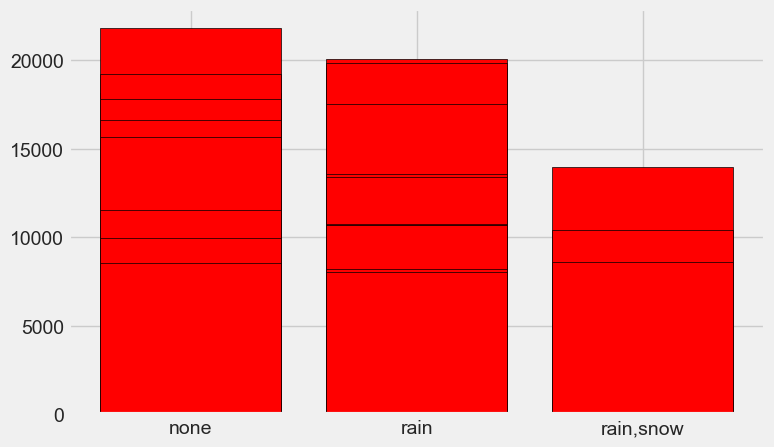

In [305]:
target_year = 2020
twentytwenty_df = merged_df[merged_df['date'].dt.year == target_year]

plt.figure(figsize=(8, 5))
plt.bar(twentytwenty_df['preciptype'], twentytwenty_df['value'], color='red', edgecolor='black')

<BarContainer object of 363 artists>

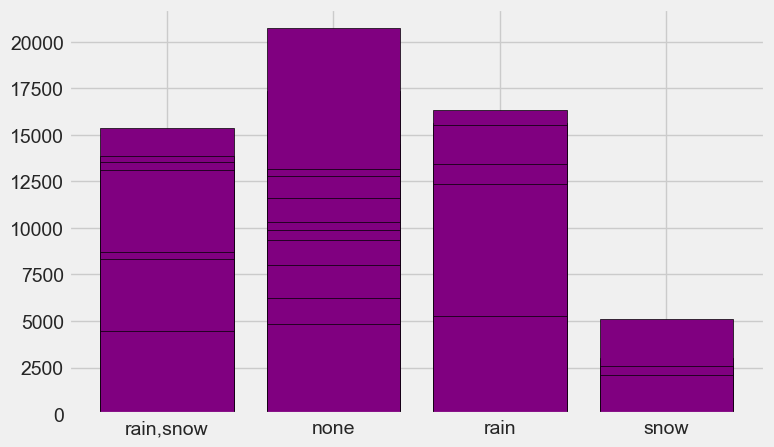

In [306]:
target_year = 2021
twentytwenty_df = merged_df[merged_df['date'].dt.year == target_year]

plt.figure(figsize=(8, 5))
plt.bar(twentytwenty_df['preciptype'], twentytwenty_df['value'], color='purple', edgecolor='black')

<BarContainer object of 365 artists>

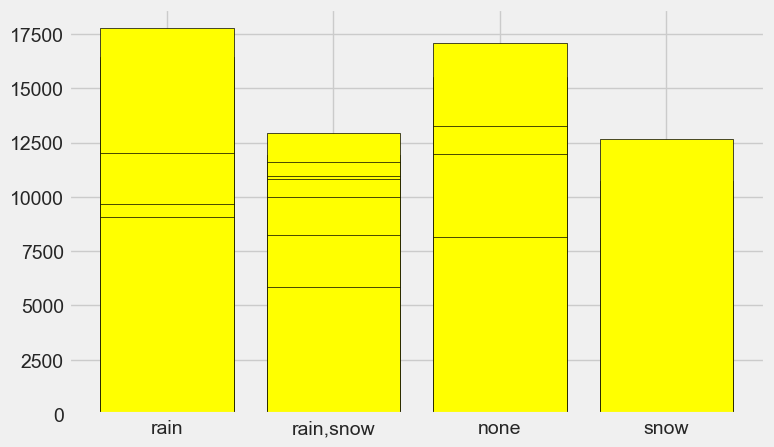

In [307]:
target_year = 2022
twentytwenty_df = merged_df[merged_df['date'].dt.year == target_year]

plt.figure(figsize=(8, 5))
plt.bar(twentytwenty_df['preciptype'], twentytwenty_df['value'], color='yellow', edgecolor='black')

<BarContainer object of 365 artists>

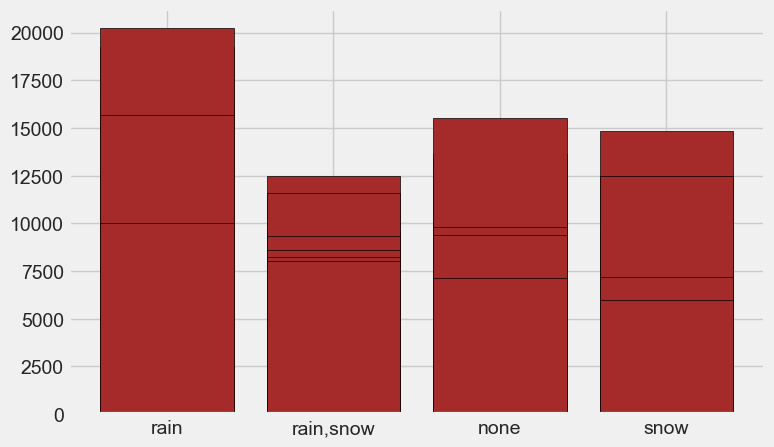

In [308]:
target_year = 2023
twentytwenty_df = merged_df[merged_df['date'].dt.year == target_year]

plt.figure(figsize=(8, 5))
plt.bar(twentytwenty_df['preciptype'], twentytwenty_df['value'], color='brown', edgecolor='black')

# Monthly Plots

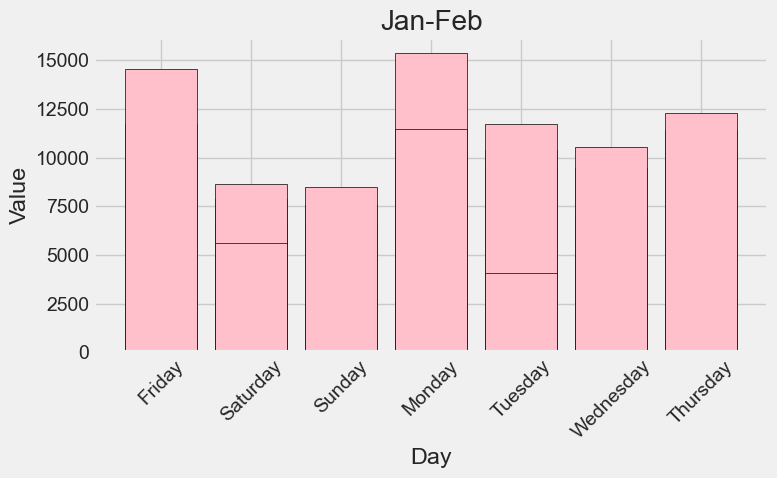

In [309]:
plot_by_months(merged_df, 2021, 1, 1, "pink", "Jan-Feb")

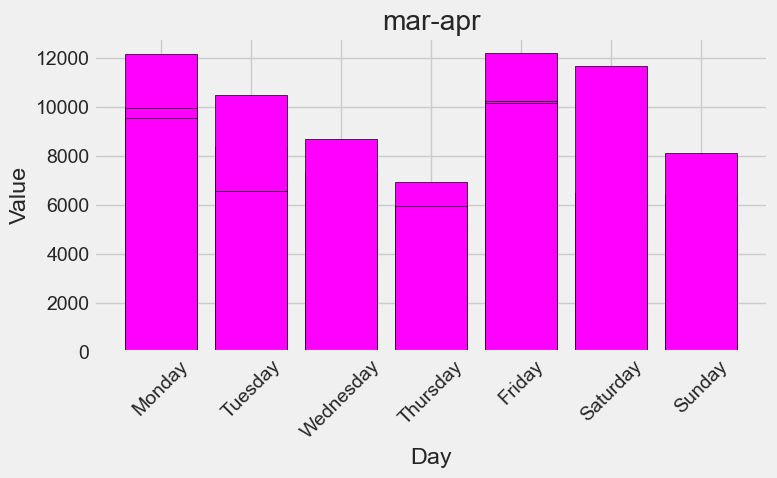

In [310]:
plot_by_months(merged_df, 2021, 2, 2, "magenta", "mar-apr")

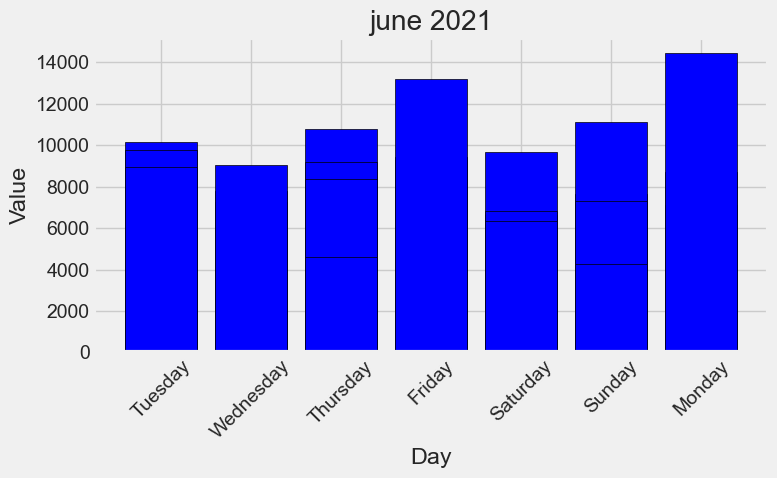

In [311]:
plot_by_months(merged_df, 2021, 6, 6, "blue", "june 2021")

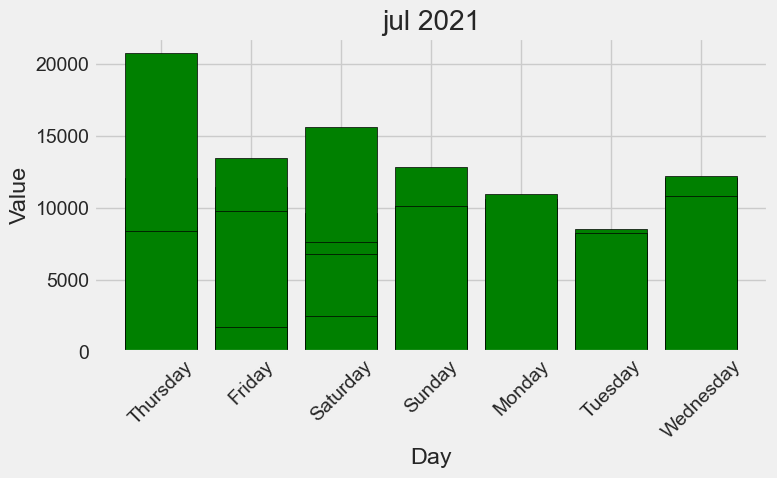

In [312]:
plot_by_months(merged_df, 2021, 7, 7, "green", "jul 2021")

# Daily Plots

In [313]:
clean_df.head()

,date,value,day
0,2018-11-18,4390,Sunday
1,2018-11-19,8335,Monday
2,2018-11-20,6946,Tuesday
3,2018-11-21,8350,Wednesday
4,2018-11-22,11054,Thursday


In [314]:
type(clean_df["date"][0])

pandas._libs.tslibs.timestamps.Timestamp

<BarContainer object of 31 artists>

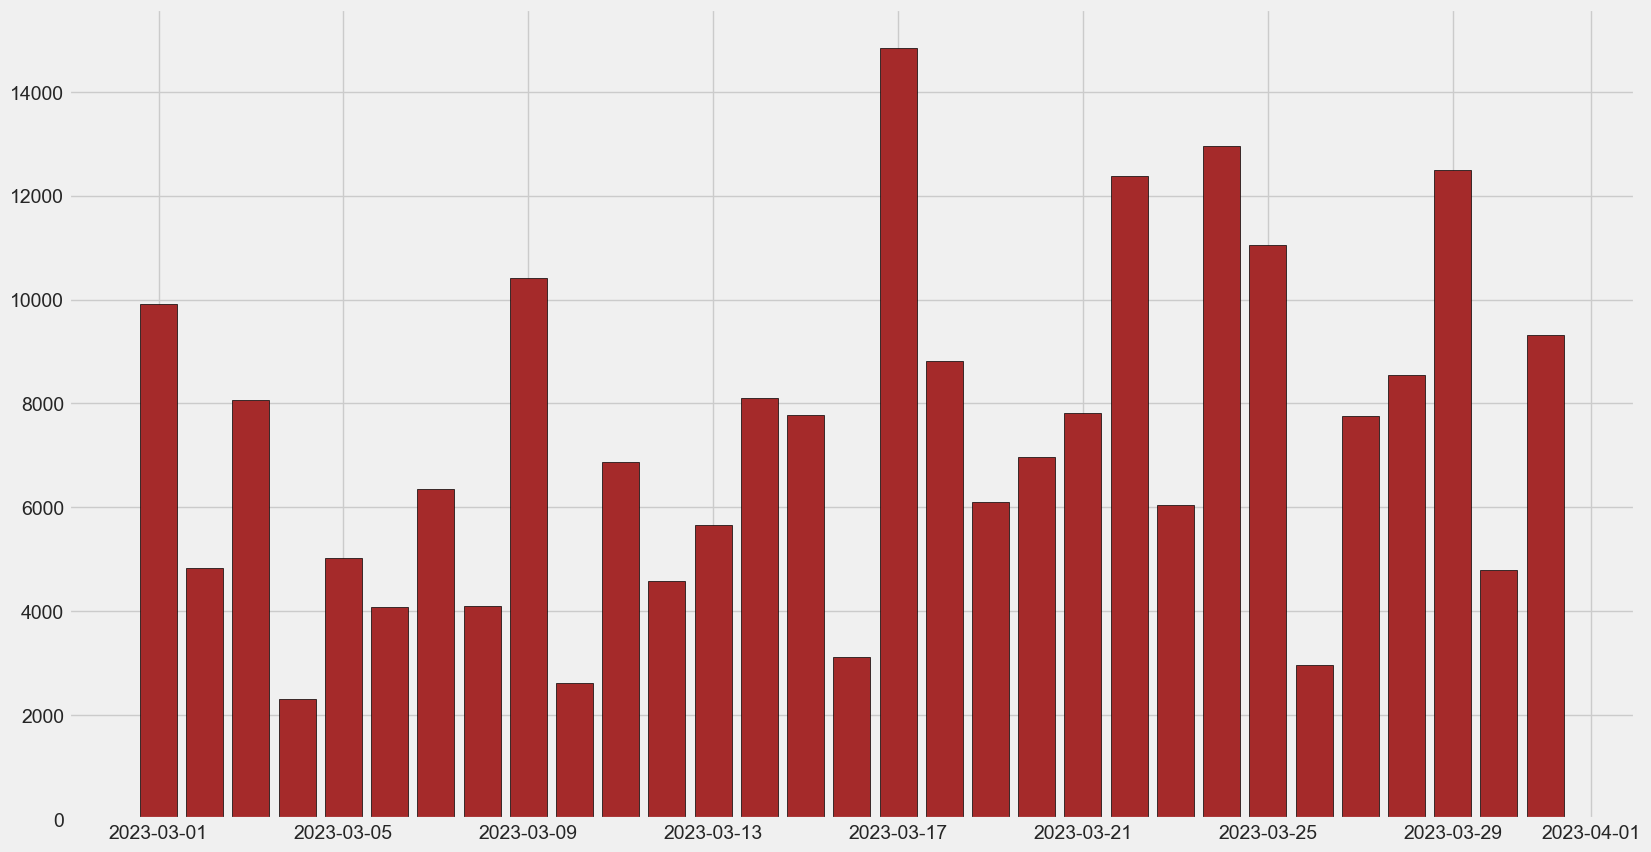

In [315]:
mar_df = clean_df[clean_df['date'].dt.month == 3]  
mar_2023_df = mar_df[mar_df['date'].dt.year == 2023]

plt.figure(figsize=(18, 10))
plt.bar(mar_2023_df['date'], mar_2023_df['value'], color='brown', edgecolor='black')

<BarContainer object of 28 artists>

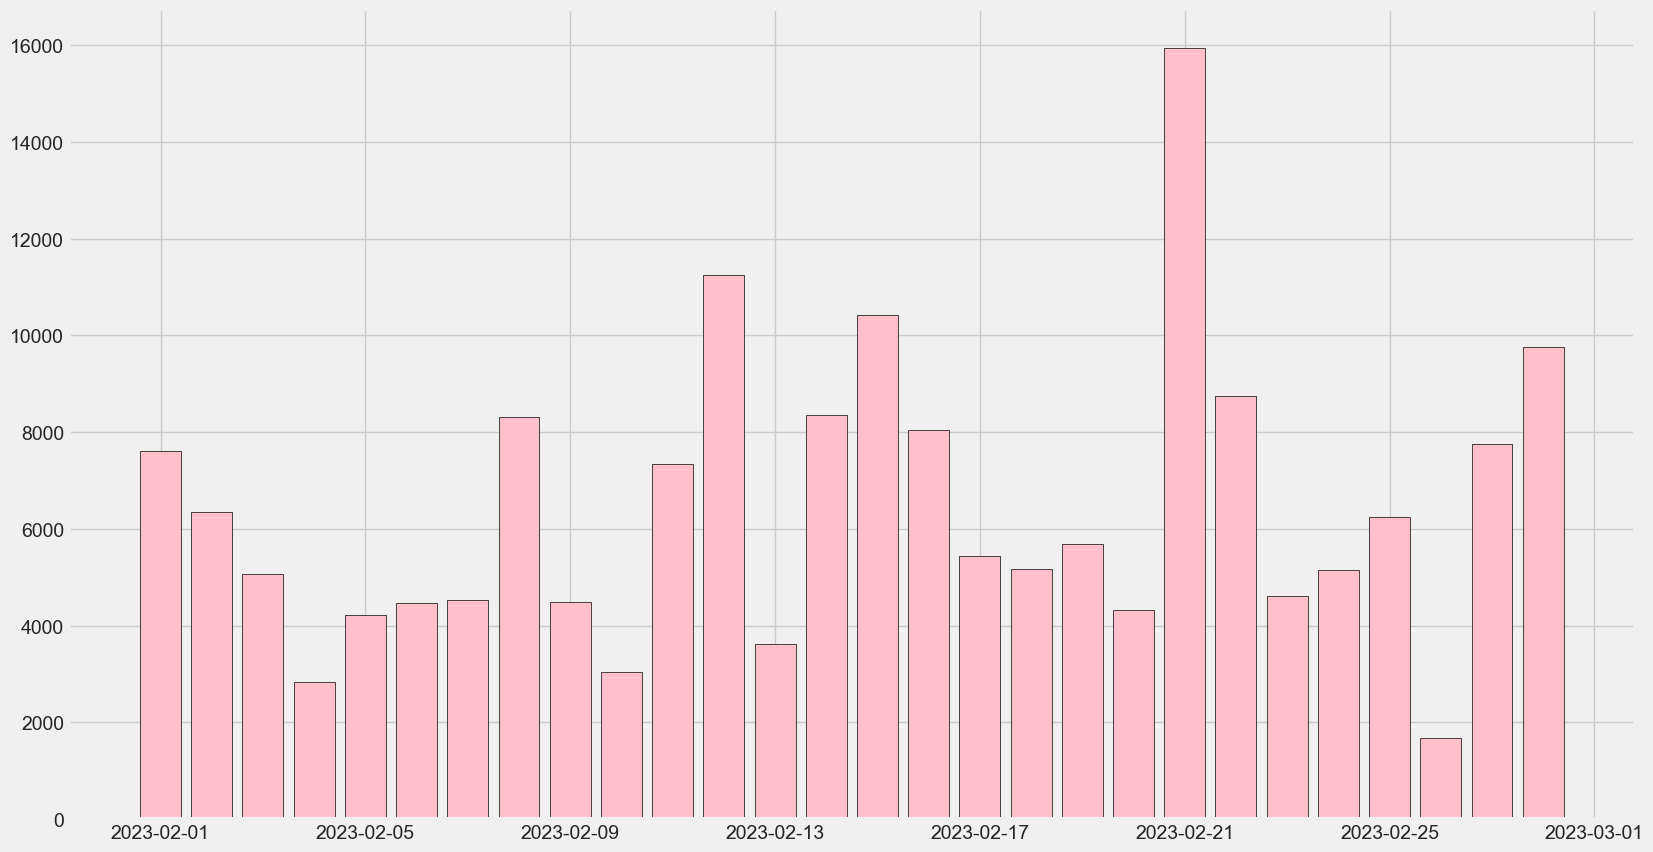

In [316]:
feb_df = clean_df[clean_df['date'].dt.month == 2]  
feb_2023_df = feb_df[feb_df['date'].dt.year == 2023]

plt.figure(figsize=(18, 10))
plt.bar(feb_2023_df['date'], feb_2023_df['value'], color='pink', edgecolor='black')

<BarContainer object of 90 artists>

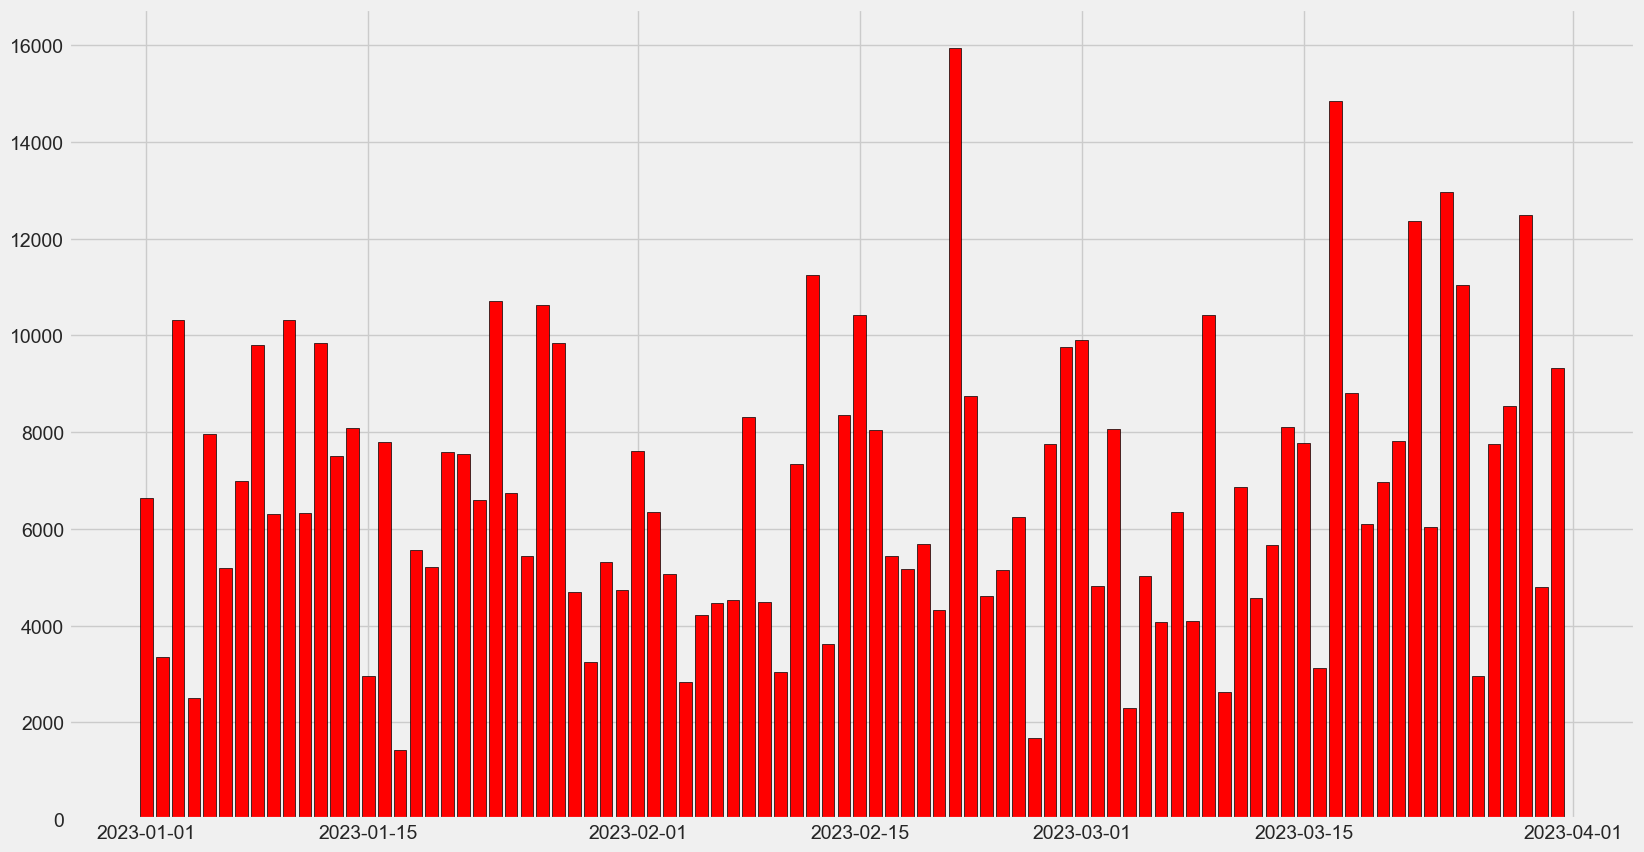

In [317]:
jan_df = clean_df[clean_df['date'].dt.month == 1]  
jan_2023_df = jan_df[jan_df['date'].dt.year == 2023]

first_quart_df = pd.concat([jan_2023_df, feb_2023_df, mar_2023_df], axis=0)

plt.figure(figsize=(18, 10))
plt.bar(first_quart_df['date'], first_quart_df['value'], color='red', edgecolor='black')

<BarContainer object of 363 artists>

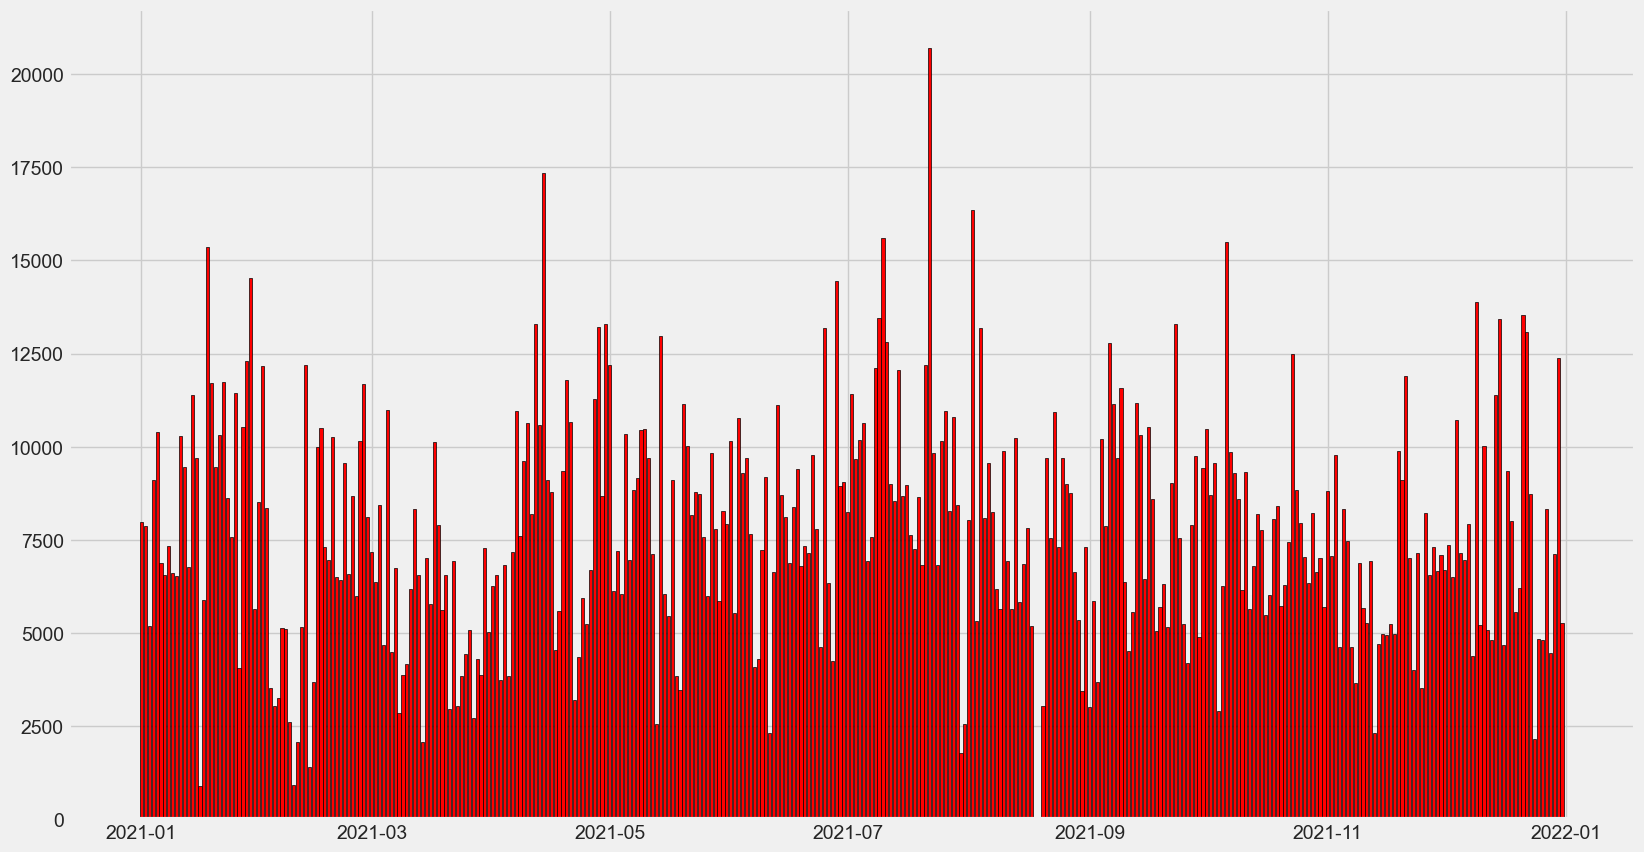

In [318]:
annu_21_df = clean_df[clean_df['date'].dt.year == 2021]

plt.figure(figsize=(18, 10))
plt.bar(annu_21_df['date'], annu_21_df['value'], color='red', edgecolor='black')

<BarContainer object of 365 artists>

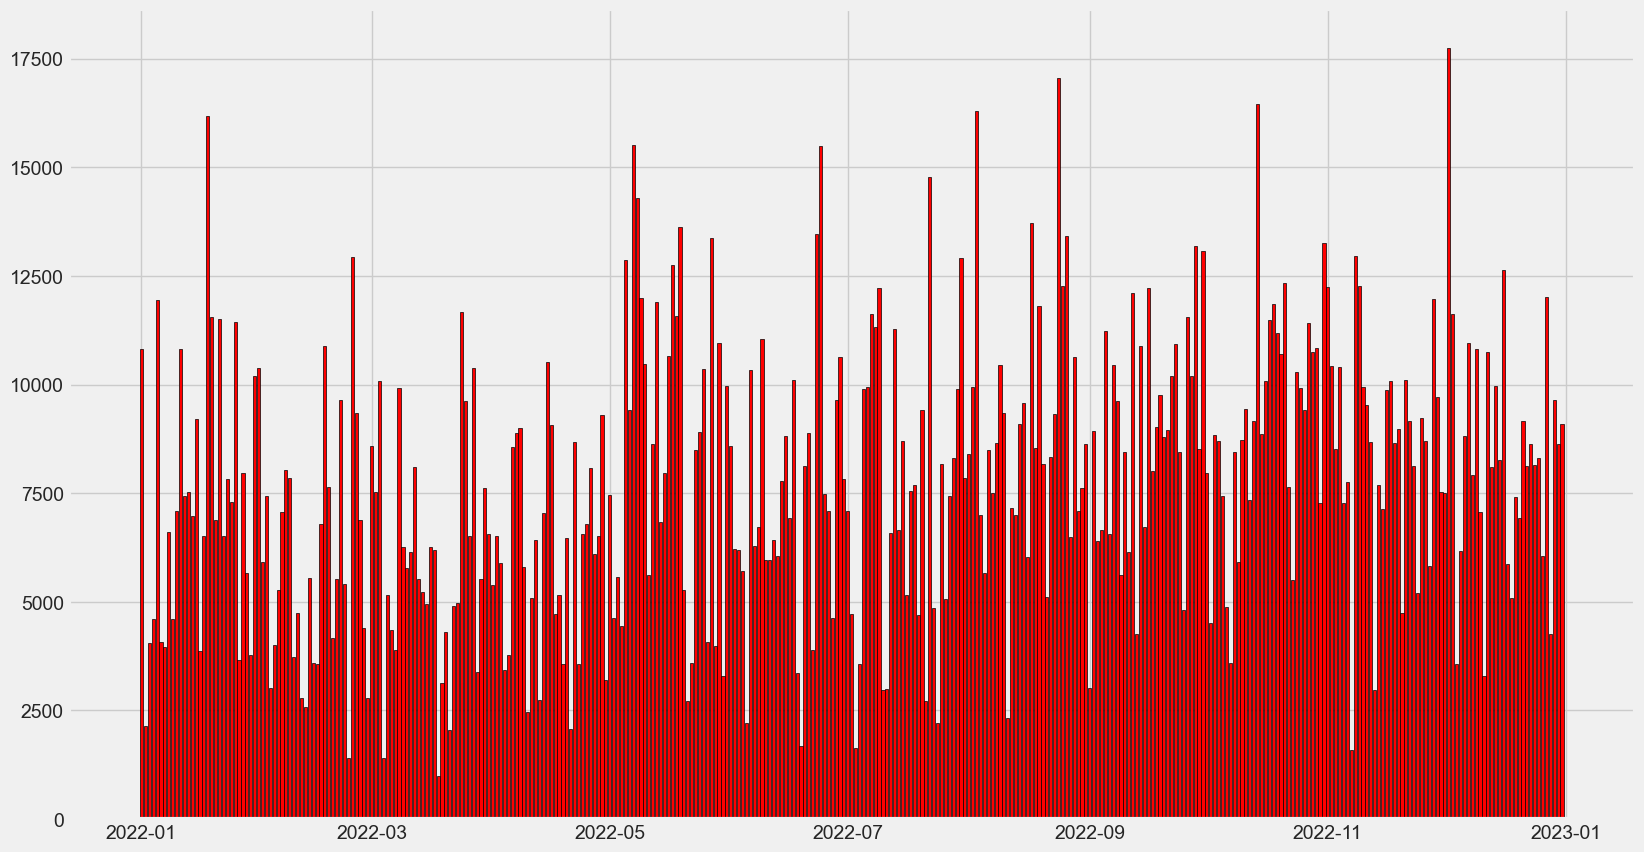

In [319]:
annu_22_df = clean_df[clean_df['date'].dt.year == 2022]

plt.figure(figsize=(18, 10))
plt.bar(annu_22_df['date'], annu_22_df['value'], color='red', edgecolor='black')

<BarContainer object of 1093 artists>

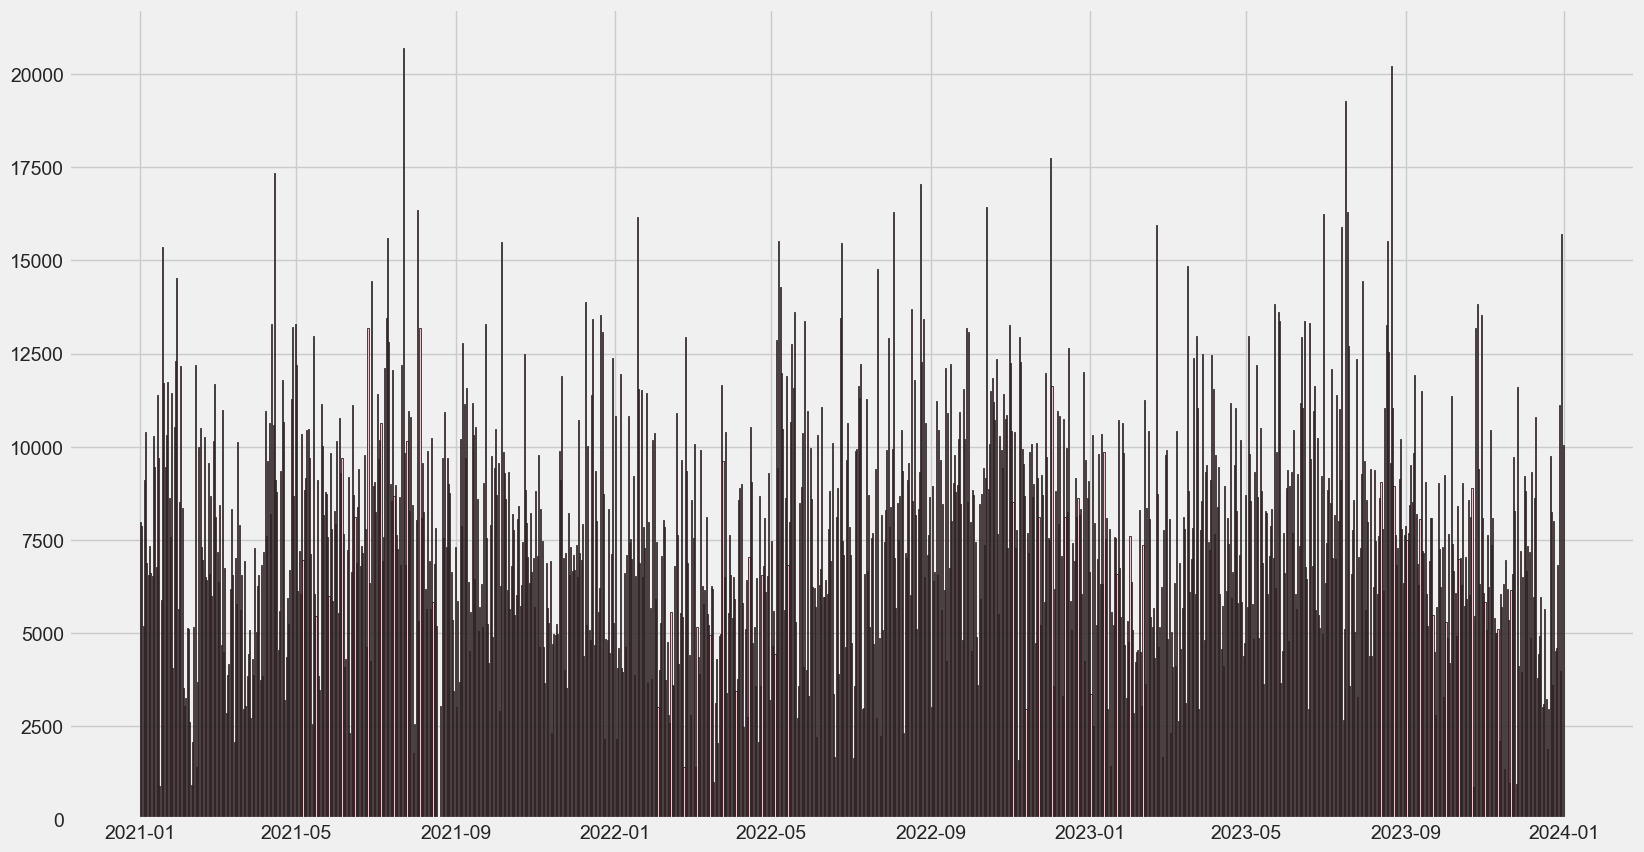

In [320]:
annu_23_df = clean_df[clean_df['date'].dt.year == 2023]

twenty_one_three_df = pd.concat([annu_21_df, annu_22_df, annu_23_df], axis=0)

plt.figure(figsize=(18, 10))
plt.bar(twenty_one_three_df['date'], twenty_one_three_df['value'], color='pink', edgecolor='black')

# Stock Analysis

In [321]:
ma_day = [20, 50]

for ma in ma_day:
    column_name = f"MA for {ma} days"
    twenty_one_two_df[column_name] = twenty_one_two_df['value'].rolling(ma).mean()

twenty_one_two_df

,date,value,day,MA for 10 days,MA for 20 days,MA for 50 days,MA for 100 days,MA for 150 days,MA for 200 days
775,2021-01-01,7989,Friday,NaN,NaN,NaN,NaN,NaN,NaN
776,2021-01-02,7881,Saturday,NaN,NaN,NaN,NaN,NaN,NaN
777,2021-01-03,5189,Sunday,NaN,NaN,NaN,NaN,NaN,NaN
778,2021-01-04,9112,Monday,NaN,NaN,NaN,NaN,NaN,NaN
779,2021-01-05,10402,Tuesday,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
1498,2022-12-27,12015,Tuesday,NaN,8228.55,8600.60,NaN,NaN,NaN
1499,2022-12-28,4251,Wednesday,NaN,8044.85,8426.58,NaN,NaN,NaN
1500,2022-12-29,9654,Thursday,NaN,7986.80,8374.34,NaN,NaN,NaN
1501,2022-12-30,8635,Friday,NaN,8065.15,8348.10,NaN,NaN,NaN


In [322]:
annu_21_df.plot(x='date', y=['value', 'MA for 20 days', 'MA for 50 days'])

KeyError: "['MA for 20 days', 'MA for 50 days'] not in index"

In [246]:
twenty_one_two_df = pd.concat([annu_21_df, annu_22_df], axis=0)

<Axes: xlabel='date'>

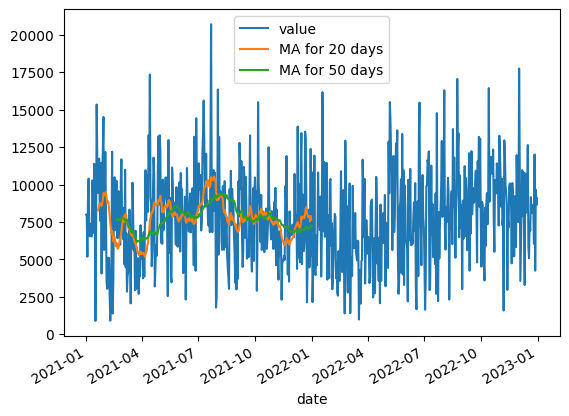

In [247]:
twenty_one_two_df.plot(x='date', y=['value', 'MA for 20 days', 'MA for 50 days'])